# EDA — Datasets used by Neural Probabilistic Circuits (NPC)

Análisis exploratorio de los cuatro datasets usados en el paper *Neural Probabilistic
Circuits: Enabling Compositional and Interpretable Predictions through Logical
Reasoning* (Chen et al., 2025, arXiv:2501.07021), replicando la lógica de construcción
de atributos y clases del código oficial (`uiuctml/npc-dataset-utils`,
`uiuctml/npc-models`), para preparar la comparación KDM vs NPC de la tesis.

**Datasets:** MNIST-Addition · GTSRB · CelebA · AwA2

Todas las figuras se guardan en `notebooks/figures/`.


In [1]:

import json
import os
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110

DATA_DIR = r"C:\Users\bspd2\Maestria\Tesis_KDM_NPC\data"
FIG_DIR = r"C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures"
os.makedirs(FIG_DIR, exist_ok=True)

SEED = 42


def savefig(name):
    path = os.path.join(FIG_DIR, name)
    plt.tight_layout()
    plt.savefig(path, bbox_inches="tight")
    print("Saved", path)
    plt.show()


## 1. MNIST-Addition

Construido siguiendo exactamente `npc-dataset-utils/mnist.py::createProcessedInstances`:
se combinan **los 70,000 dígitos** de MNIST (train+test) en pares aleatorios
(`random.Random(seed).shuffle`, seed=42), concatenados horizontalmente; la suma de
los dos dígitos es la clase, y cada dígito individual es uno de los dos atributos
(`Number-First`, `Number-Second`). Resultado esperado: 35,000 muestras, 19 clases
(0–18), 2 atributos de 10 valores cada uno.


In [2]:

import torchvision

mnist_train = torchvision.datasets.MNIST(root=f"{DATA_DIR}/mnist", train=True, download=False)
mnist_test = torchvision.datasets.MNIST(root=f"{DATA_DIR}/mnist", train=False, download=False)

images = np.concatenate([mnist_train.data.numpy(), mnist_test.data.numpy()], axis=0)
labels = np.concatenate([mnist_train.targets.numpy(), mnist_test.targets.numpy()], axis=0)
print("Total digit images:", images.shape, "labels:", labels.shape)

digit_balance = pd.Series(labels).value_counts().sort_index()
print(digit_balance)


Total digit images: (70000, 28, 28) labels: (70000,)
0    6903
1    7877
2    6990
3    7141
4    6824
5    6313
6    6876
7    7293
8    6825
9    6958
Name: count, dtype: int64


In [3]:

# Replicate NPC's exact pairing procedure: shuffle all 70,000 digit indices with seed 42, pair consecutively
indices = list(range(len(labels)))
random.Random(SEED).shuffle(indices)

pairs_first = indices[0::2]
pairs_second = indices[1::2]
n_pairs = min(len(pairs_first), len(pairs_second))
pairs_first, pairs_second = pairs_first[:n_pairs], pairs_second[:n_pairs]

attr_first = labels[pairs_first]
attr_second = labels[pairs_second]
class_sum = attr_first + attr_second

mnist_add = pd.DataFrame({
    "idx_first": pairs_first, "idx_second": pairs_second,
    "number_first": attr_first, "number_second": attr_second, "class_sum": class_sum,
})
print(f"MNIST-Addition reconstructed: {len(mnist_add)} samples "
      f"(paper reports 35,000 from 70,000/2)")
mnist_add.head()


MNIST-Addition reconstructed: 35000 samples (paper reports 35,000 from 70,000/2)


,idx_first,idx_second,number_first,number_second,class_sum
0,21209,63787,3,3,6
1,69973,60535,9,4,13
2,51656,57672,8,7,15
3,32513,23436,4,8,12
4,24151,771,0,5,5


Saved C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures\mnist_addition_distributions.png


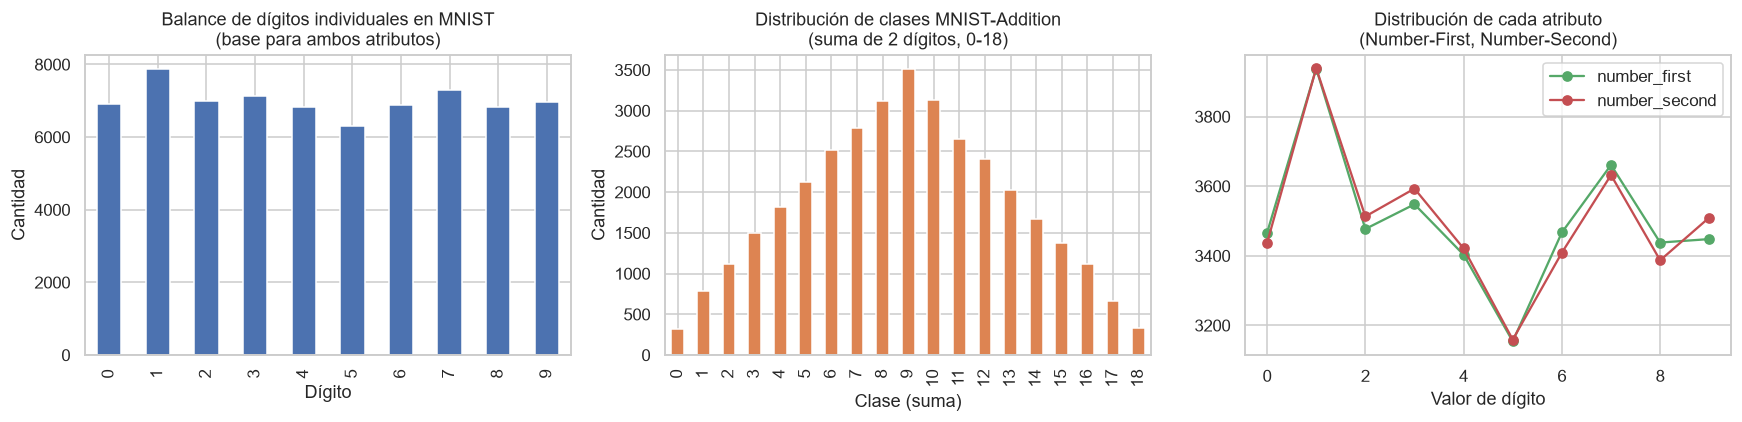

In [4]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

digit_balance.plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Balance de dígitos individuales en MNIST\n(base para ambos atributos)")
axes[0].set_xlabel("Dígito"); axes[0].set_ylabel("Cantidad")

mnist_add["class_sum"].value_counts().sort_index().plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Distribución de clases MNIST-Addition\n(suma de 2 dígitos, 0-18)")
axes[1].set_xlabel("Clase (suma)"); axes[1].set_ylabel("Cantidad")

for col, color in [("number_first", "#55A868"), ("number_second", "#C44E52")]:
    mnist_add[col].value_counts().sort_index().plot(kind="line", marker="o", ax=axes[2],
                                                      label=col, color=color)
axes[2].set_title("Distribución de cada atributo\n(Number-First, Number-Second)")
axes[2].set_xlabel("Valor de dígito"); axes[2].legend()

savefig("mnist_addition_distributions.png")


**Observación clave:** la distribución de clases (suma de dos dígitos) es
**triangular**, no uniforme — la clase 9 (suma central) es ~10x más frecuente que las
clases extremas 0 o 18, porque hay muchas más combinaciones de dígitos que suman 9
que combinaciones que suman 0 (solo 0+0) o 18 (solo 9+9). Esto es un desbalance de
clases inherente al diseño del dataset, no un artefacto de muestreo, y ambos atributos
(Number-First, Number-Second) son individualmente ~uniformes (uno por dígito de
MNIST) pero **conjuntamente determinan la clase de forma no lineal** — consistente
con el hallazgo del paper (Sec. 5.3.2) de que remover cualquiera de los dos atributos
degrada fuertemente el desempeño, porque ambos son "decisivos".

Saved C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures\mnist_addition_samples.png


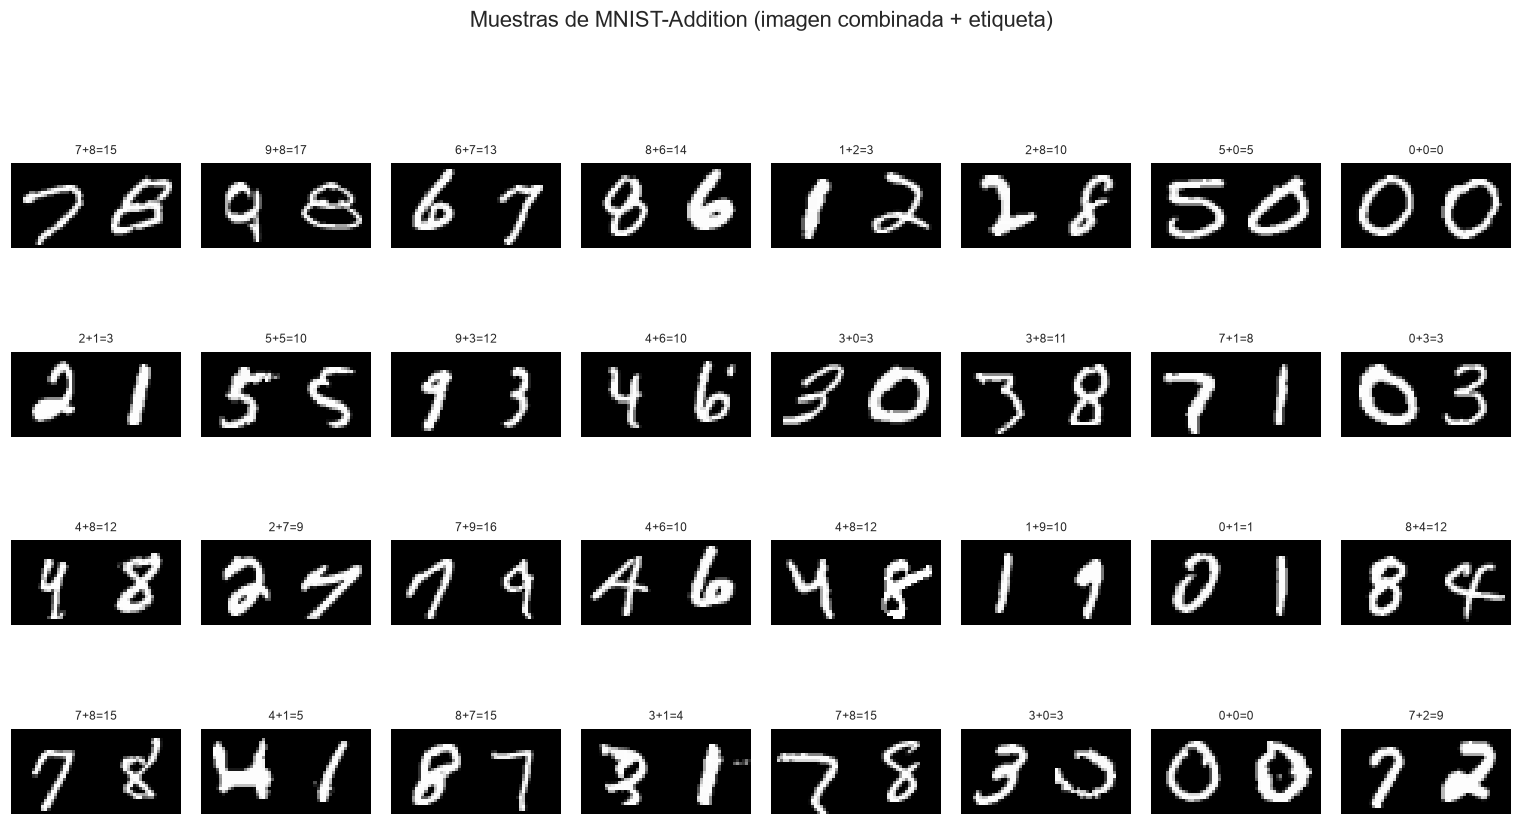

In [5]:

fig, axes = plt.subplots(4, 8, figsize=(14, 8))
rng = random.Random(SEED)
sample_idx = rng.sample(range(len(mnist_add)), 32)

for ax, i in zip(axes.flat, sample_idx):
    row = mnist_add.iloc[i]
    img_first = images[row["idx_first"]]
    img_second = images[row["idx_second"]]
    combined = np.concatenate([img_first, img_second], axis=1)
    ax.imshow(combined, cmap="gray")
    ax.set_title(f"{row['number_first']}+{row['number_second']}={row['class_sum']}", fontsize=8)
    ax.axis("off")

fig.suptitle("Muestras de MNIST-Addition (imagen combinada + etiqueta)", y=1.02)
savefig("mnist_addition_samples.png")


## 2. GTSRB (German Traffic Sign Recognition Benchmark)

43 clases nativas (idénticas a `npc-dataset-utils/gtsrb.py::class_names`).
**Nota importante:** el esquema de 4 atributos semánticos (`Color`, `Shape`,
`Symbol`, `Text`) que describe el paper (Tabla 5) **no está incluido en el
repositorio público `npc-dataset-utils`** — a diferencia de CelebA y AwA2, cuyo
`attribute_types` sí está en el código, GTSRB solo tiene el mapeo de carpetas a
nombres de clase; las anotaciones de atributos parecen haberse hecho manualmente
(vía `label.py`, la herramienta GUI) y no se distribuyen en este repo. Por eso esta
sección tiene dos partes: (1) un EDA completo y verificado sobre las imágenes reales
descargadas, y (2) una reconstrucción **manual, transcrita del texto del paper**
(Tabla 5 y Apéndice E) del esquema de atributos — marcada explícitamente como
derivada del paper, no del código, y sujeta a posible ruido de transcripción del PDF.


In [6]:

gtsrb_train = torchvision.datasets.GTSRB(root=f"{DATA_DIR}/gtsrb", split="train", download=False)
gtsrb_test = torchvision.datasets.GTSRB(root=f"{DATA_DIR}/gtsrb", split="test", download=False)

class_names = {
    0: "speed-20", 1: "speed-30", 2: "speed-50", 3: "speed-60", 4: "speed-70",
    5: "speed-80", 6: "end-speed-80", 7: "speed-100", 8: "speed-120", 9: "no-overtaking",
    10: "no-overtaking-heavy", 11: "crossroads", 12: "priority-road", 13: "yield",
    14: "stop", 15: "road-closed", 16: "no-heavy-goods", 17: "no-entry", 18: "other-danger",
    19: "curve-left", 20: "curve-right", 21: "double-curve-left", 22: "uneven-road",
    23: "slippery-road", 24: "road-narrows-right", 25: "roadworks", 26: "traffic-signals",
    27: "pedestrians-crossing", 28: "children", 29: "bicycles-crossing", 30: "ice-or-snow",
    31: "wild-animals", 32: "end-of-prohibition", 33: "turn-right-ahead", 34: "turn-left-ahead",
    35: "go-straight", 36: "go-straight-or-right", 37: "go-straight-or-left", 38: "keep-right",
    39: "keep-left", 40: "roundabout", 41: "end-no-overtaking", 42: "end-no-overtaking-heavy",
}

gtsrb_labels_train = [s[1] for s in gtsrb_train._samples]
gtsrb_labels_test = [s[1] for s in gtsrb_test._samples]
gtsrb_all = pd.DataFrame({
    "class_id": gtsrb_labels_train + gtsrb_labels_test,
    "split": ["train"] * len(gtsrb_labels_train) + ["test"] * len(gtsrb_labels_test),
})
gtsrb_all["class_name"] = gtsrb_all["class_id"].map(class_names)
print(f"GTSRB total images: {len(gtsrb_all)} (train={len(gtsrb_labels_train)}, test={len(gtsrb_labels_test)})")
print(f"Classes: {gtsrb_all['class_id'].nunique()}")


GTSRB total images: 39270 (train=26640, test=12630)
Classes: 43


Saved C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures\gtsrb_class_distribution.png


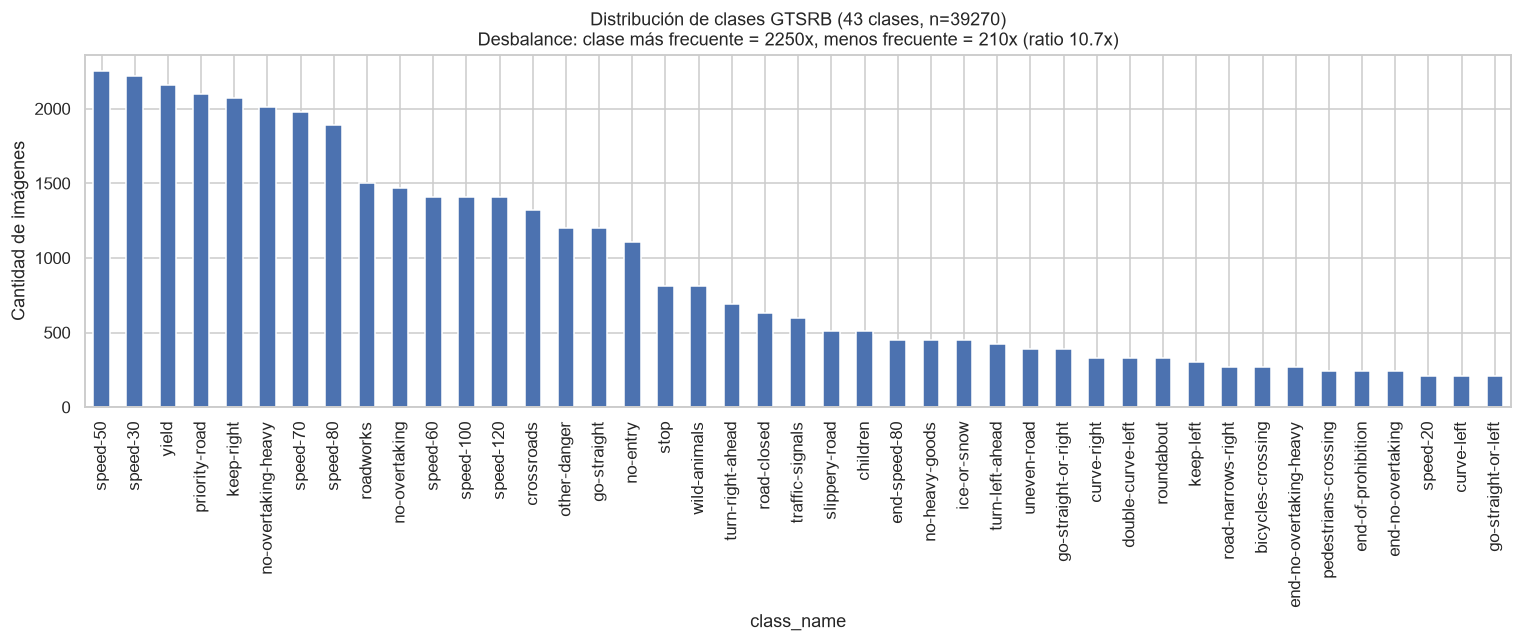

In [7]:

fig, ax = plt.subplots(figsize=(14, 6))
counts = gtsrb_all["class_name"].value_counts()
counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_title(f"Distribución de clases GTSRB (43 clases, n={len(gtsrb_all)})\n"
             f"Desbalance: clase más frecuente = {counts.max()}x, menos frecuente = {counts.min()}x "
             f"(ratio {counts.max()/counts.min():.1f}x)")
ax.set_ylabel("Cantidad de imágenes")
savefig("gtsrb_class_distribution.png")


Saved C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures\gtsrb_samples.png


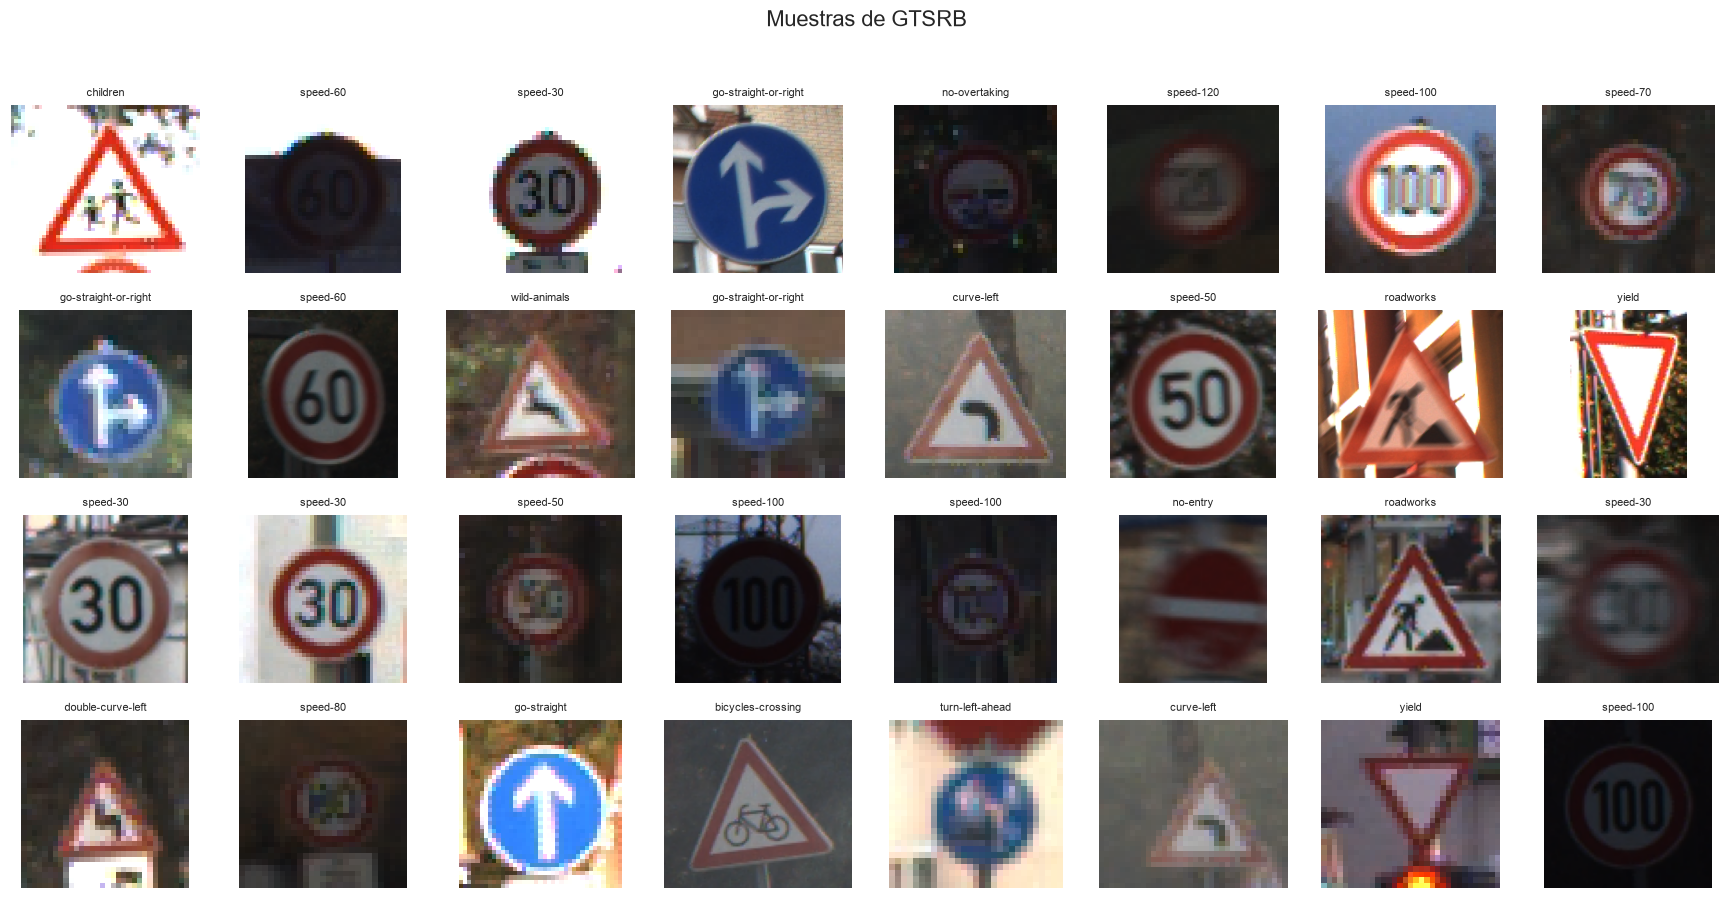

In [8]:

fig, axes = plt.subplots(4, 8, figsize=(16, 8))
rng = random.Random(SEED)
sample_positions = rng.sample(range(len(gtsrb_train)), 32)

for ax, pos in zip(axes.flat, sample_positions):
    img, label = gtsrb_train[pos]
    ax.imshow(img)
    ax.set_title(class_names[label], fontsize=7)
    ax.axis("off")

fig.suptitle("Muestras de GTSRB", y=1.02)
savefig("gtsrb_samples.png")


In [9]:

# Manual, paper-derived attribute schema (Table 5) — cardinalities only, high-confidence
gtsrb_attr_schema = {
    "color": ["blue", "red", "white"],
    "shape": ["circle", "diamond", "octagon", "triangle"],
    "symbol": ["arrow-consecutive-turns", "arrow-down-left", "arrow-down-right", "arrow-left",
               "arrow-right", "arrow-roundabout", "arrow-up", "arrow-up-and-left",
               "arrow-up-and-right", "bicycle", "bump", "car", "car-truck", "car-two", "deer",
               "exclamation-mark", "ice-or-snow", "person", "person-two", "road-narrows",
               "roadworks", "slash", "text", "traffic-signal", "truck", "undefined"],
    "text": ["20", "30", "50", "60", "70", "80", "100", "120", "stop", "undefined"],
}
for k, v in gtsrb_attr_schema.items():
    print(f"{k}: {len(v)} values -> {v}")


color: 3 values -> ['blue', 'red', 'white']
shape: 4 values -> ['circle', 'diamond', 'octagon', 'triangle']
symbol: 26 values -> ['arrow-consecutive-turns', 'arrow-down-left', 'arrow-down-right', 'arrow-left', 'arrow-right', 'arrow-roundabout', 'arrow-up', 'arrow-up-and-left', 'arrow-up-and-right', 'bicycle', 'bump', 'car', 'car-truck', 'car-two', 'deer', 'exclamation-mark', 'ice-or-snow', 'person', 'person-two', 'road-narrows', 'roadworks', 'slash', 'text', 'traffic-signal', 'truck', 'undefined']
text: 10 values -> ['20', '30', '50', '60', '70', '80', '100', '120', 'stop', 'undefined']


In [10]:

# Manual, paper-derived class -> attribute mapping (transcribed from Appendix E, Tables 7-8)
# CAVEAT: transcribed from PDF text extraction of a dense two-column table; treat as
# illustrative of the decisive/non-decisive attribute pattern, not a verified ground truth.
gtsrb_class_attributes = {
    "speed-20":  dict(color="red", shape="circle", symbol="text", text="20"),
    "speed-30":  dict(color="red", shape="circle", symbol="text", text="30"),
    "speed-50":  dict(color="red", shape="circle", symbol="text", text="50"),
    "speed-60":  dict(color="red", shape="circle", symbol="text", text="60"),
    "speed-70":  dict(color="red", shape="circle", symbol="text", text="70"),
    "speed-80":  dict(color="red", shape="circle", symbol="text", text="80"),
    "end-speed-80": dict(color="white", shape="circle", symbol="text", text="80"),
    "speed-100": dict(color="red", shape="circle", symbol="text", text="100"),
    "speed-120": dict(color="red", shape="circle", symbol="text", text="120"),
    "no-overtaking": dict(color="red", shape="circle", symbol="car-two", text="undefined"),
    "no-overtaking-heavy": dict(color="red", shape="circle", symbol="car-truck", text="undefined"),
    "priority-road": dict(color="white", shape="diamond", symbol="undefined", text="undefined"),
    "yield": dict(color="red", shape="triangle", symbol="undefined", text="undefined"),
    "stop": dict(color="red", shape="octagon", symbol="text", text="stop"),
    "road-closed": dict(color="red", shape="circle", symbol="undefined", text="undefined"),
    "no-heavy-goods": dict(color="red", shape="circle", symbol="truck", text="undefined"),
    "no-entry": dict(color="red", shape="circle", symbol="slash", text="undefined"),
    "other-danger": dict(color="red", shape="triangle", symbol="exclamation-mark", text="undefined"),
    "curve-left": dict(color="red", shape="triangle", symbol="arrow-left", text="undefined"),
    "curve-right": dict(color="red", shape="triangle", symbol="arrow-right", text="undefined"),
    "double-curve-left": dict(color="red", shape="triangle", symbol="arrow-consecutive-turns", text="undefined"),
    "uneven-road": dict(color="red", shape="triangle", symbol="bump", text="undefined"),
    "slippery-road": dict(color="red", shape="triangle", symbol="car", text="undefined"),
    "road-narrows-right": dict(color="red", shape="triangle", symbol="road-narrows", text="undefined"),
    "roadworks": dict(color="red", shape="triangle", symbol="roadworks", text="undefined"),
    "traffic-signals": dict(color="red", shape="triangle", symbol="traffic-signal", text="undefined"),
    "pedestrians-crossing": dict(color="red", shape="triangle", symbol="person", text="undefined"),
    "children": dict(color="red", shape="triangle", symbol="person-two", text="undefined"),
    "bicycles-crossing": dict(color="red", shape="triangle", symbol="bicycle", text="undefined"),
    "ice-or-snow": dict(color="red", shape="triangle", symbol="ice-or-snow", text="undefined"),
    "wild-animals": dict(color="red", shape="triangle", symbol="deer", text="undefined"),
    "end-of-prohibition": dict(color="white", shape="circle", symbol="undefined", text="undefined"),
    "turn-right-ahead": dict(color="blue", shape="circle", symbol="arrow-right", text="undefined"),
    "turn-left-ahead": dict(color="blue", shape="circle", symbol="arrow-left", text="undefined"),
    "go-straight": dict(color="blue", shape="circle", symbol="arrow-up", text="undefined"),
    "go-straight-or-right": dict(color="blue", shape="circle", symbol="arrow-up-and-right", text="undefined"),
    "go-straight-or-left": dict(color="blue", shape="circle", symbol="arrow-up-and-left", text="undefined"),
    "keep-right": dict(color="blue", shape="circle", symbol="arrow-down-right", text="undefined"),
    "keep-left": dict(color="blue", shape="circle", symbol="arrow-down-left", text="undefined"),
    "roundabout": dict(color="blue", shape="circle", symbol="arrow-roundabout", text="undefined"),
    "end-no-overtaking": dict(color="white", shape="circle", symbol="car-two", text="undefined"),
    "end-no-overtaking-heavy": dict(color="white", shape="circle", symbol="car-truck", text="undefined"),
}
print(f"Classes with attribute mapping recovered from paper text: {len(gtsrb_class_attributes)} / 43")
gtsrb_attr_df = pd.DataFrame.from_dict(gtsrb_class_attributes, orient="index")
gtsrb_attr_df.index.name = "class_name"
gtsrb_attr_df.reset_index()


Classes with attribute mapping recovered from paper text: 42 / 43


,class_name,color,shape,symbol,text
0,speed-20,red,circle,text,20
1,speed-30,red,circle,text,30
2,speed-50,red,circle,text,50
3,speed-60,red,circle,text,60
4,speed-70,red,circle,text,70
5,speed-80,red,circle,text,80
6,end-speed-80,white,circle,text,80
7,speed-100,red,circle,text,100
8,speed-120,red,circle,text,120
9,no-overtaking,red,circle,car-two,undefined


Saved C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures\gtsrb_attribute_schema_paper_derived.png


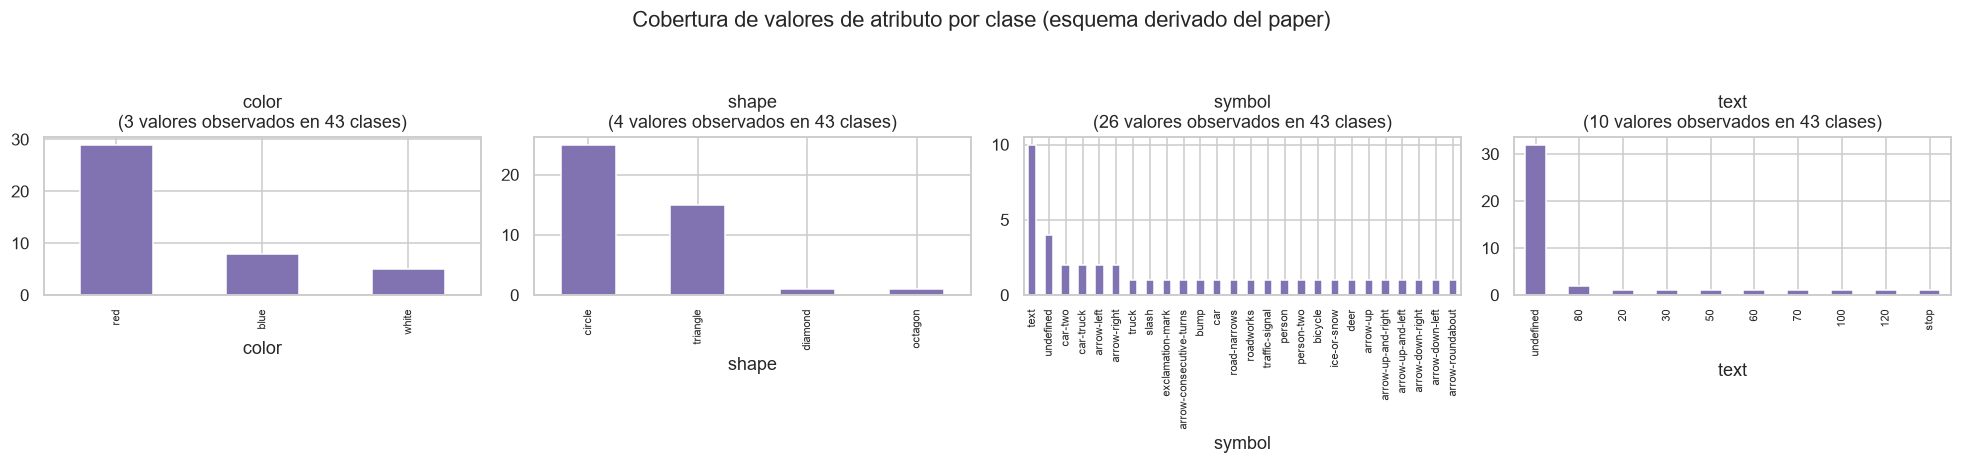

In [11]:

fig, axes = plt.subplots(1, 4, figsize=(18, 4))
for ax, attr in zip(axes, ["color", "shape", "symbol", "text"]):
    vc = gtsrb_attr_df[attr].value_counts()
    vc.plot(kind="bar", ax=ax, color="#8172B2")
    ax.set_title(f"{attr}\n({vc.shape[0]} valores observados en 43 clases)")
    ax.tick_params(axis="x", labelrotation=90, labelsize=7)
fig.suptitle("Cobertura de valores de atributo por clase (esquema derivado del paper)", y=1.05)
savefig("gtsrb_attribute_schema_paper_derived.png")


**Observación clave (consistente con Sec. 5.3.2 del paper):** `Color` y
`Shape` tienen muy baja cardinalidad efectiva en las 43 clases (dominadas por
`red`/`circle` y `red`/`triangle`), por lo que son atributos **poco decisivos** —
muchas clases distintas comparten el mismo valor. `Symbol` y `Text`, en cambio,
tienen alta cardinalidad y son casi 1-a-1 con la clase dentro de cada grupo
color+shape — son los atributos **decisivos**, y el paper reporta que excluirlos
en inferencia causa una caída de exactitud mucho mayor que excluir Color o Shape.

## 3. CelebA

40 conceptos binarios anotados para 202,599 imágenes. Se descargó únicamente
`list_attr_celeba.txt` (26.7MB) — **no las imágenes** (1.4GB, requieren descarga
completa desde Google Drive con cuota limitada) — porque el EDA de atributos y
clases no las necesita; se documenta esta limitación explícitamente.

Replicamos `npc-dataset-utils/celeba.py`: (1) `computeAttributeBalanceScores`
para encontrar los 8 conceptos más balanceados, (2) `attribute_types` para
agruparlos en 5 atributos, y (3) `assignClasses` para la estrategia de rebalanceo
que produce 127 clases.


In [12]:

celeba_attr = pd.read_csv(
    f"{DATA_DIR}/celeba/list_attr_celeba.txt", sep=r"\s+", skiprows=1, index_col=0,
)
celeba_attr.index.name = "image_id"
print("Shape:", celeba_attr.shape)
celeba_attr_bool = (celeba_attr == 1)
celeba_attr.head(3)


Shape: (202599, 40)


,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
image_id,,,,,,,,,,,,,,,,,,,,,
000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1


In [13]:

# Replicate celeba.py::computeAttributeBalanceScores (lower = more balanced)
attribute_blacklist = {"Male"}
balance_scores = {}
for col in celeba_attr_bool.columns:
    if col in attribute_blacklist:
        continue
    count_true = celeba_attr_bool[col].sum()
    count_false = len(celeba_attr_bool) - count_true
    balance_scores[col] = abs(int(count_true) - int(count_false))

balance_df = pd.Series(balance_scores).sort_values()
top8 = balance_df.head(8)
print("Top-8 most balanced binary concepts (NPC's selection criterion):")
print(top8)


Top-8 most balanced binary concepts (NPC's selection criterion):
Attractive              5067
Mouth_Slightly_Open     6715
Smiling                 7261
Wearing_Lipstick       11169
High_Cheekbones        18221
Heavy_Makeup           45819
Wavy_Hair              73111
Oval_Face              87465
dtype: int64


Saved C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures\celeba_attribute_balance_scores.png


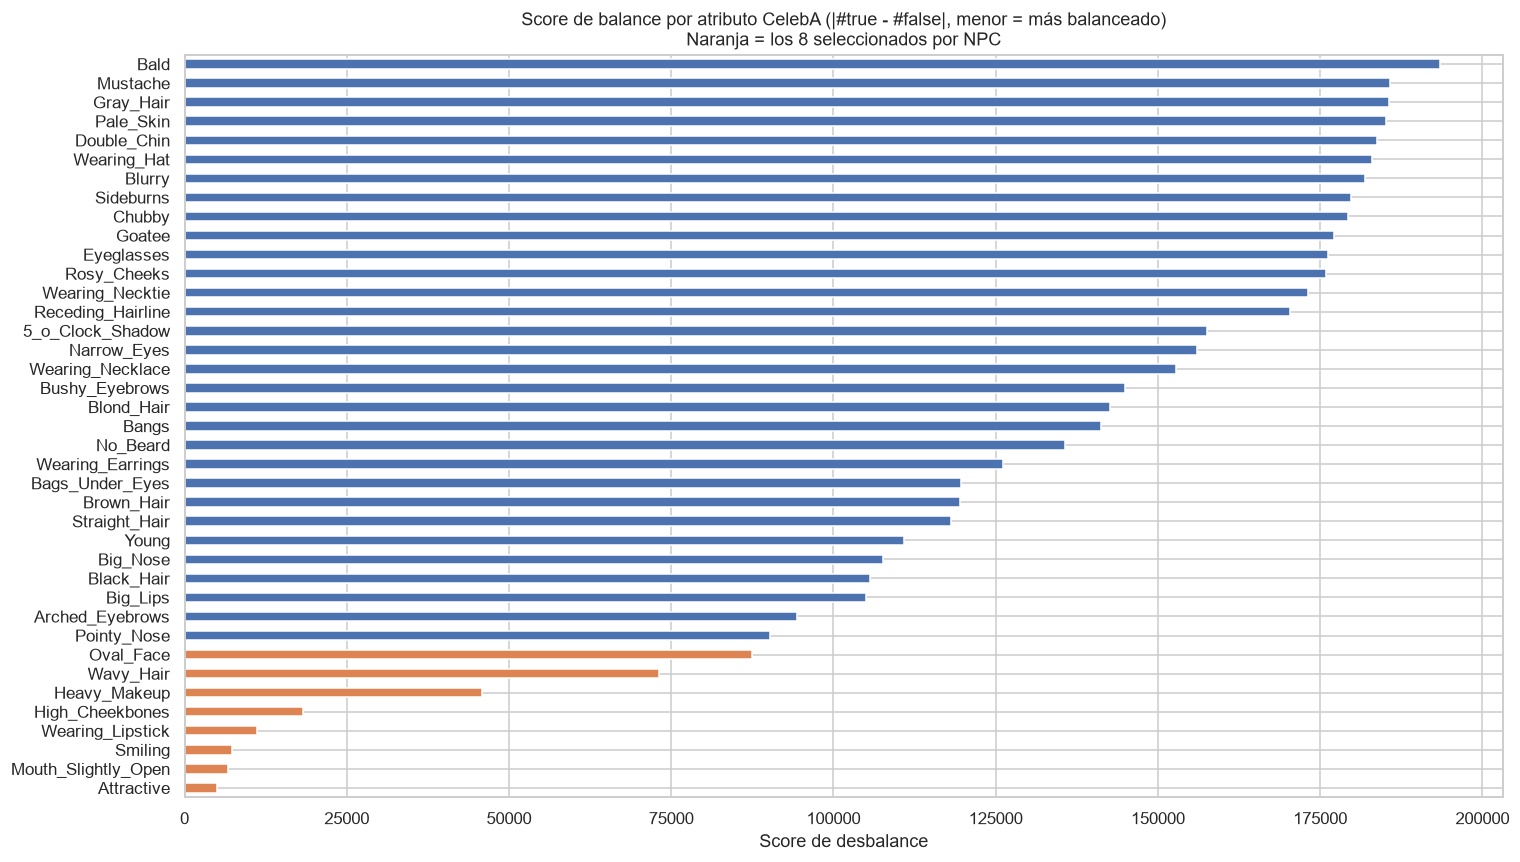

In [14]:

fig, ax = plt.subplots(figsize=(14, 8))
colors = ["#DD8452" if c in top8.index else "#4C72B0" for c in balance_df.index]
balance_df.plot(kind="barh", ax=ax, color=colors)
ax.set_title("Score de balance por atributo CelebA (|#true - #false|, menor = más balanceado)\n"
             "Naranja = los 8 seleccionados por NPC")
ax.set_xlabel("Score de desbalance")
savefig("celeba_attribute_balance_scores.png")


In [15]:

# Group into NPC's 5 attributes (npc-dataset-utils/celeba.py::attribute_types)
attribute_types = {
    "mouth": ["Mouth_Slightly_Open", "Smiling"],
    "face": ["High_Cheekbones", "Oval_Face"],
    "cosmetic": ["Heavy_Makeup", "Wearing_Lipstick"],
    "hair": ["Wavy_Hair"],
    "appearance": ["Attractive"],
}
selected_concepts = [c for concepts in attribute_types.values() for c in concepts]
print("NPC-selected concepts present in top-8 balance ranking:",
      set(selected_concepts) <= set(top8.index))
print("Selected:", selected_concepts)


NPC-selected concepts present in top-8 balance ranking: True
Selected: ['Mouth_Slightly_Open', 'Smiling', 'High_Cheekbones', 'Oval_Face', 'Heavy_Makeup', 'Wearing_Lipstick', 'Wavy_Hair', 'Attractive']


In [16]:

# Multi-valued attribute analysis: within each grouped attribute, how often are
# MULTIPLE concepts simultaneously true (the "multi_hot": true case confirmed in
# npc-dataset-utils/celeba.py and handled via uniform-probability split in
# npc-models/dataset.py:83-91)
rows = []
for attr_name, concepts in attribute_types.items():
    if len(concepts) < 2:
        continue
    active_count = celeba_attr_bool[concepts].sum(axis=1)
    for k in range(len(concepts) + 1):
        rows.append({"attribute": attr_name, "n_active_values": k,
                      "count": int((active_count == k).sum())})

multi_df = pd.DataFrame(rows)
pivot = multi_df.pivot(index="attribute", columns="n_active_values", values="count")
print(pivot)
print("\n'mouth' and 'cosmetic' each have 2 concepts: n_active_values=2 rows are the "
      "genuinely multi-hot cases (both concepts true), which get split 0.5/0.5 per "
      "Eq. 2 / dataset.py's uniform-probability conversion.")


n_active_values       0      1      2
attribute                            
cosmetic         105014  21065  76520
face              88760  77922  35917
mouth             81339  46909  74351

'mouth' and 'cosmetic' each have 2 concepts: n_active_values=2 rows are the genuinely multi-hot cases (both concepts true), which get split 0.5/0.5 per Eq. 2 / dataset.py's uniform-probability conversion.


Saved C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures\celeba_multivalued_attributes.png


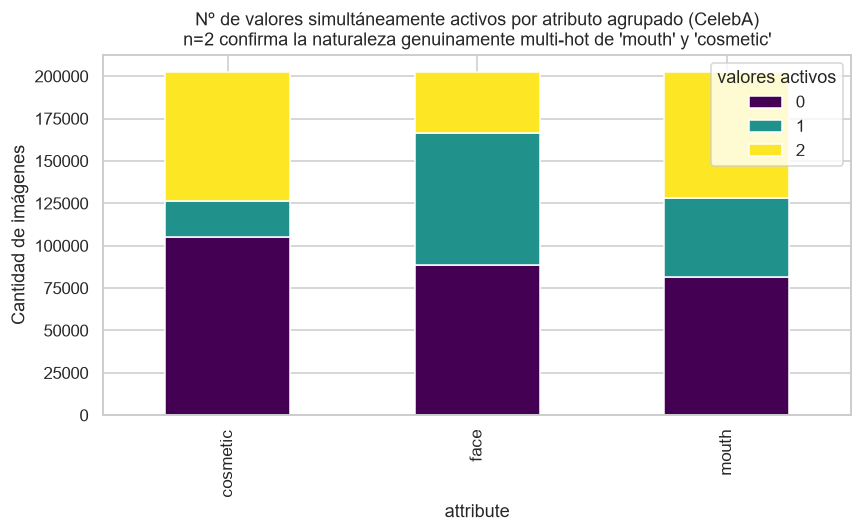

In [17]:

fig, ax = plt.subplots(figsize=(8, 5))
pivot.plot(kind="bar", stacked=True, ax=ax, colormap="viridis")
ax.set_title("Nº de valores simultáneamente activos por atributo agrupado (CelebA)\n"
             "n=2 confirma la naturaleza genuinamente multi-hot de 'mouth' y 'cosmetic'")
ax.set_ylabel("Cantidad de imágenes")
ax.legend(title="valores activos")
savefig("celeba_multivalued_attributes.png")


In [18]:

# Replicate celeba.py::assignClasses — the rebalancing strategy (largest group
# paired with smallest, etc.) that produces the paper's 127 classes
def attribute_assignment_string(row):
    s = ""
    for concepts in attribute_types.values():
        active = [c for c in concepts if row[c]]
        s += "".join(active) if active else ""
    return s

celeba_sample = celeba_attr_bool  # full 202,599 — cheap since it's just boolean columns
assignment_strings = celeba_sample.apply(attribute_assignment_string, axis=1)
group_sizes = assignment_strings.value_counts()
print(f"Raw attribute-combination groups (before rebalancing): {len(group_sizes)}")
print(group_sizes.describe())


Raw attribute-combination groups (before rebalancing): 254
count      254.000000
mean       797.633858
std       2040.062768
min          1.000000
25%         29.000000
50%        160.000000
75%        625.750000
max      23588.000000
Name: count, dtype: float64


Saved C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures\celeba_class_rebalancing.png


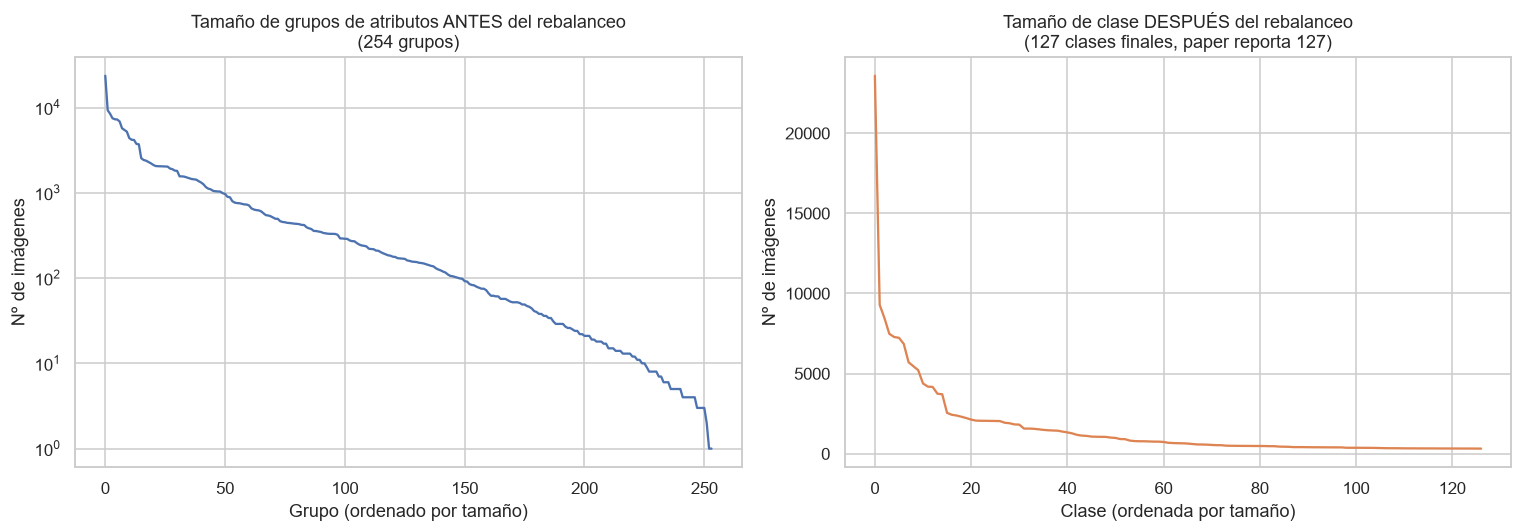

Reconstructed final class count: 127 (paper: 127)


In [19]:

sorted_groups = group_sizes.sort_values(ascending=False).values
n_final_classes = len(sorted_groups) // 2
paired_sizes = sorted_groups[:n_final_classes] + sorted_groups[-n_final_classes:][::-1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
pd.Series(sorted_groups).plot(kind="line", ax=axes[0], color="#4C72B0")
axes[0].set_title(f"Tamaño de grupos de atributos ANTES del rebalanceo\n({len(sorted_groups)} grupos)")
axes[0].set_xlabel("Grupo (ordenado por tamaño)"); axes[0].set_ylabel("Nº de imágenes")
axes[0].set_yscale("log")

pd.Series(sorted(paired_sizes, reverse=True)).plot(kind="line", ax=axes[1], color="#DD8452")
axes[1].set_title(f"Tamaño de clase DESPUÉS del rebalanceo\n({n_final_classes} clases finales, "
                   f"paper reporta 127)")
axes[1].set_xlabel("Clase (ordenada por tamaño)"); axes[1].set_ylabel("Nº de imágenes")

savefig("celeba_class_rebalancing.png")
print(f"Reconstructed final class count: {n_final_classes} (paper: 127)")


**Observación clave:** el rebalanceo de CelebA (emparejar el grupo de
atributos más grande con el más pequeño, el segundo más grande con el segundo más
pequeño, etc.) reduce drásticamente la varianza del tamaño de clase — de una
distribución con cola larga (algunos combos de atributos son muy raros, otros muy
comunes) a una distribución mucho más plana. Esto es coherente con el objetivo
explícito del paper de "balancear el dataset y aumentar su complejidad" para la
tarea de clasificación en 127 clases.

## 4. AwA2 (Animals with Attributes 2)

50 clases de animales × 85 predicados binarios (matriz clase-atributo, no
instancia-atributo: **la anotación es a nivel de clase**, todas las imágenes de
una clase comparten los mismos atributos — a diferencia de MNIST-Addition donde
varía por instancia). Se descargó solo el paquete base (32KB: `classes.txt`,
`predicates.txt`, `predicate-matrix-binary.txt`) — no las ~37,322 imágenes (13GB).


In [20]:

awa2_dir = f"{DATA_DIR}/awa2/Animals_with_Attributes2"

with open(f"{awa2_dir}/classes.txt") as f:
    awa2_classes = [line.strip().split("\t")[1] for line in f if line.strip()]

with open(f"{awa2_dir}/predicates.txt") as f:
    awa2_predicates = [line.strip().split("\t")[1] for line in f if line.strip()]

awa2_matrix = np.loadtxt(f"{awa2_dir}/predicate-matrix-binary.txt", dtype=int)
print(f"Classes: {len(awa2_classes)}, Predicates: {len(awa2_predicates)}, Matrix shape: {awa2_matrix.shape}")

awa2_df = pd.DataFrame(awa2_matrix, index=awa2_classes, columns=awa2_predicates)
awa2_df.head(3)


Classes: 50, Predicates: 85, Matrix shape: (50, 85)


,black,white,blue,brown,gray,orange,red,yellow,patches,spots,...,water,tree,cave,fierce,timid,smart,group,solitary,nestspot,domestic
antelope,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,1,0,0,0
grizzly+bear,1,0,0,1,0,0,0,0,0,0,...,0,0,1,1,0,1,0,1,0,0
killer+whale,1,1,0,0,0,0,0,0,1,1,...,1,0,0,1,0,1,1,0,0,0


Saved C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures\awa2_full_predicate_matrix.png


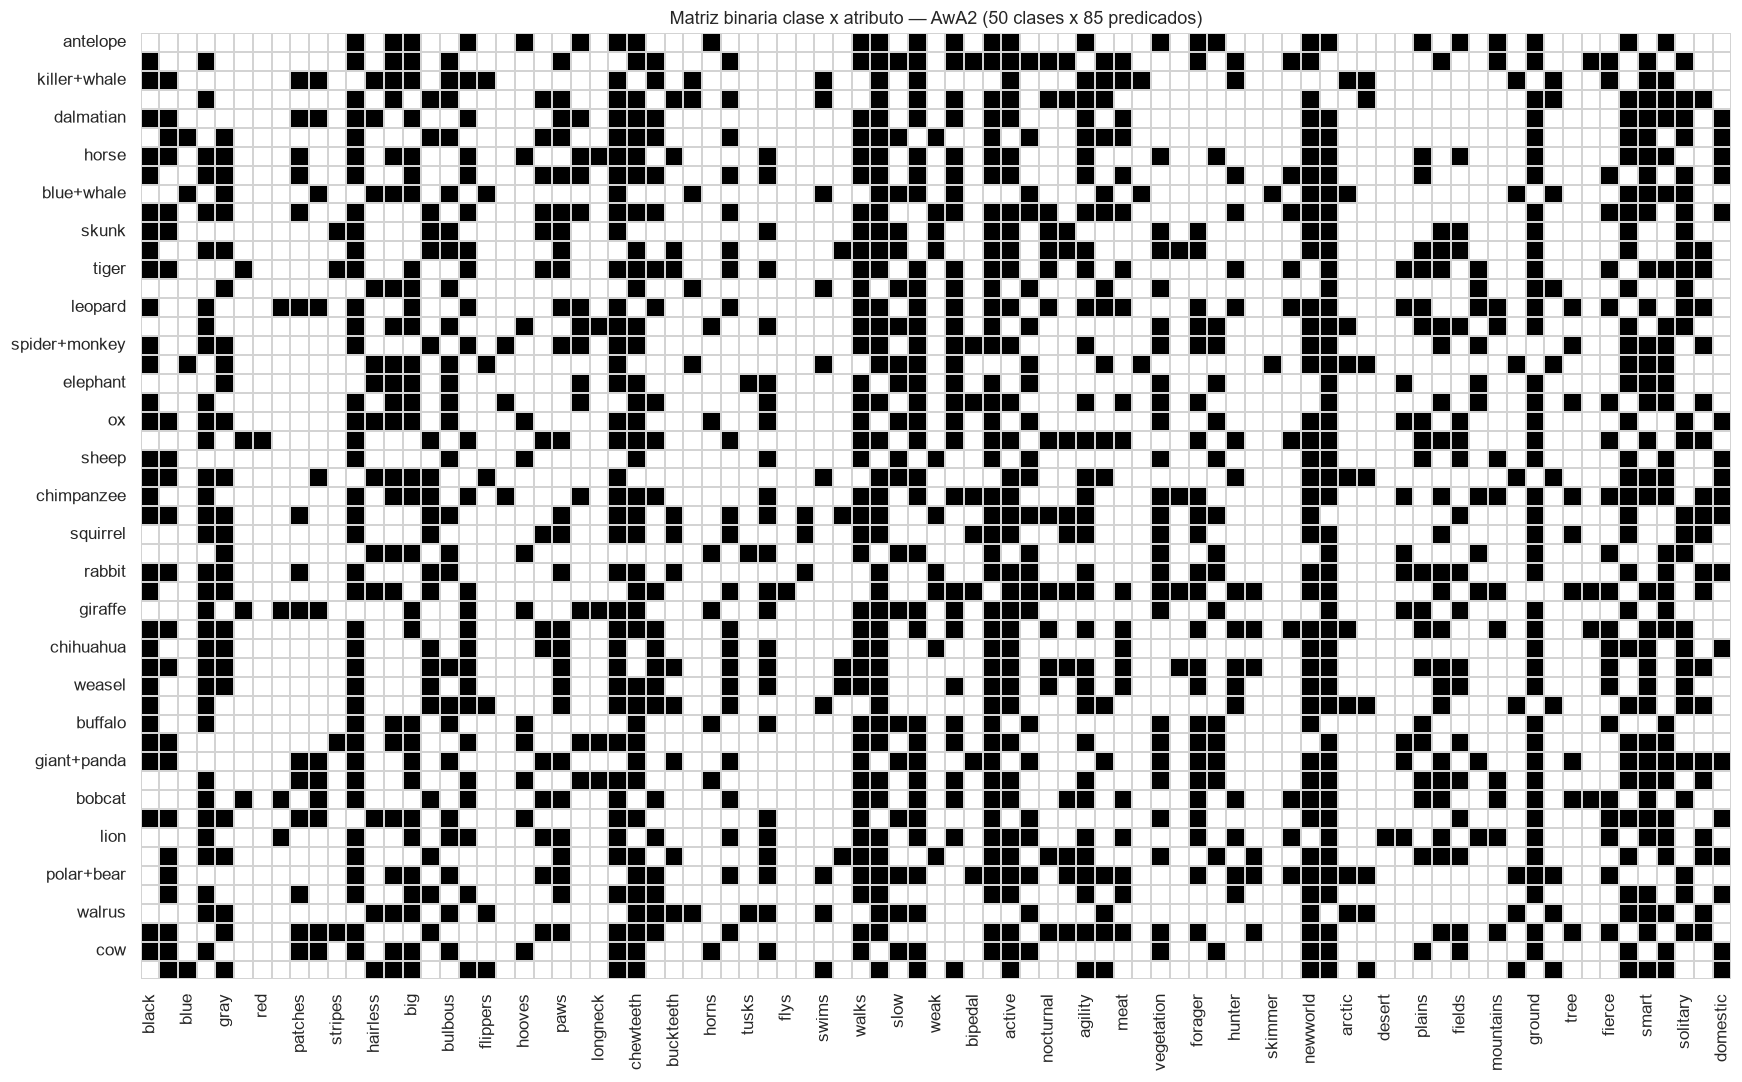

In [21]:

fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(awa2_df, cmap="Greys", cbar=False, ax=ax, linewidths=0.1, linecolor="lightgray")
ax.set_title("Matriz binaria clase x atributo — AwA2 (50 clases x 85 predicados)")
savefig("awa2_full_predicate_matrix.png")


In [22]:

# Replicate npc-dataset-utils/awa2.py::attribute_types — the 4-attribute grouping
# from 29 of the 85 predicates (56 excluded as non-visual/background/indistinctive)
attribute_types = {
    "color": ["black", "white", "blue", "brown", "gray", "orange", "red", "yellow"],
    "surface": ["patches", "spots", "stripes", "furry", "hairless", "toughskin"],
    "body": ["bulbous", "lean", "bipedal", "quadrapedal", "longleg", "longneck",
             "tail", "horns", "tusks"],
    "limb": ["flippers", "hands", "hooves", "pads", "paws", "claws"],
}
kept_predicates = [p for concepts in attribute_types.values() for p in concepts]
print(f"Predicates kept by NPC: {len(kept_predicates)} / {len(awa2_predicates)}")
print(f"Predicates excluded (non-visual/background/indistinctive): "
      f"{len(awa2_predicates) - len(kept_predicates)}")
missing = [p for p in kept_predicates if p not in awa2_predicates]
print("Any grouped predicate missing from the official 85?", missing if missing else "none")


Predicates kept by NPC: 29 / 85
Predicates excluded (non-visual/background/indistinctive): 56
Any grouped predicate missing from the official 85? none


Saved C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures\awa2_attribute_value_distributions.png


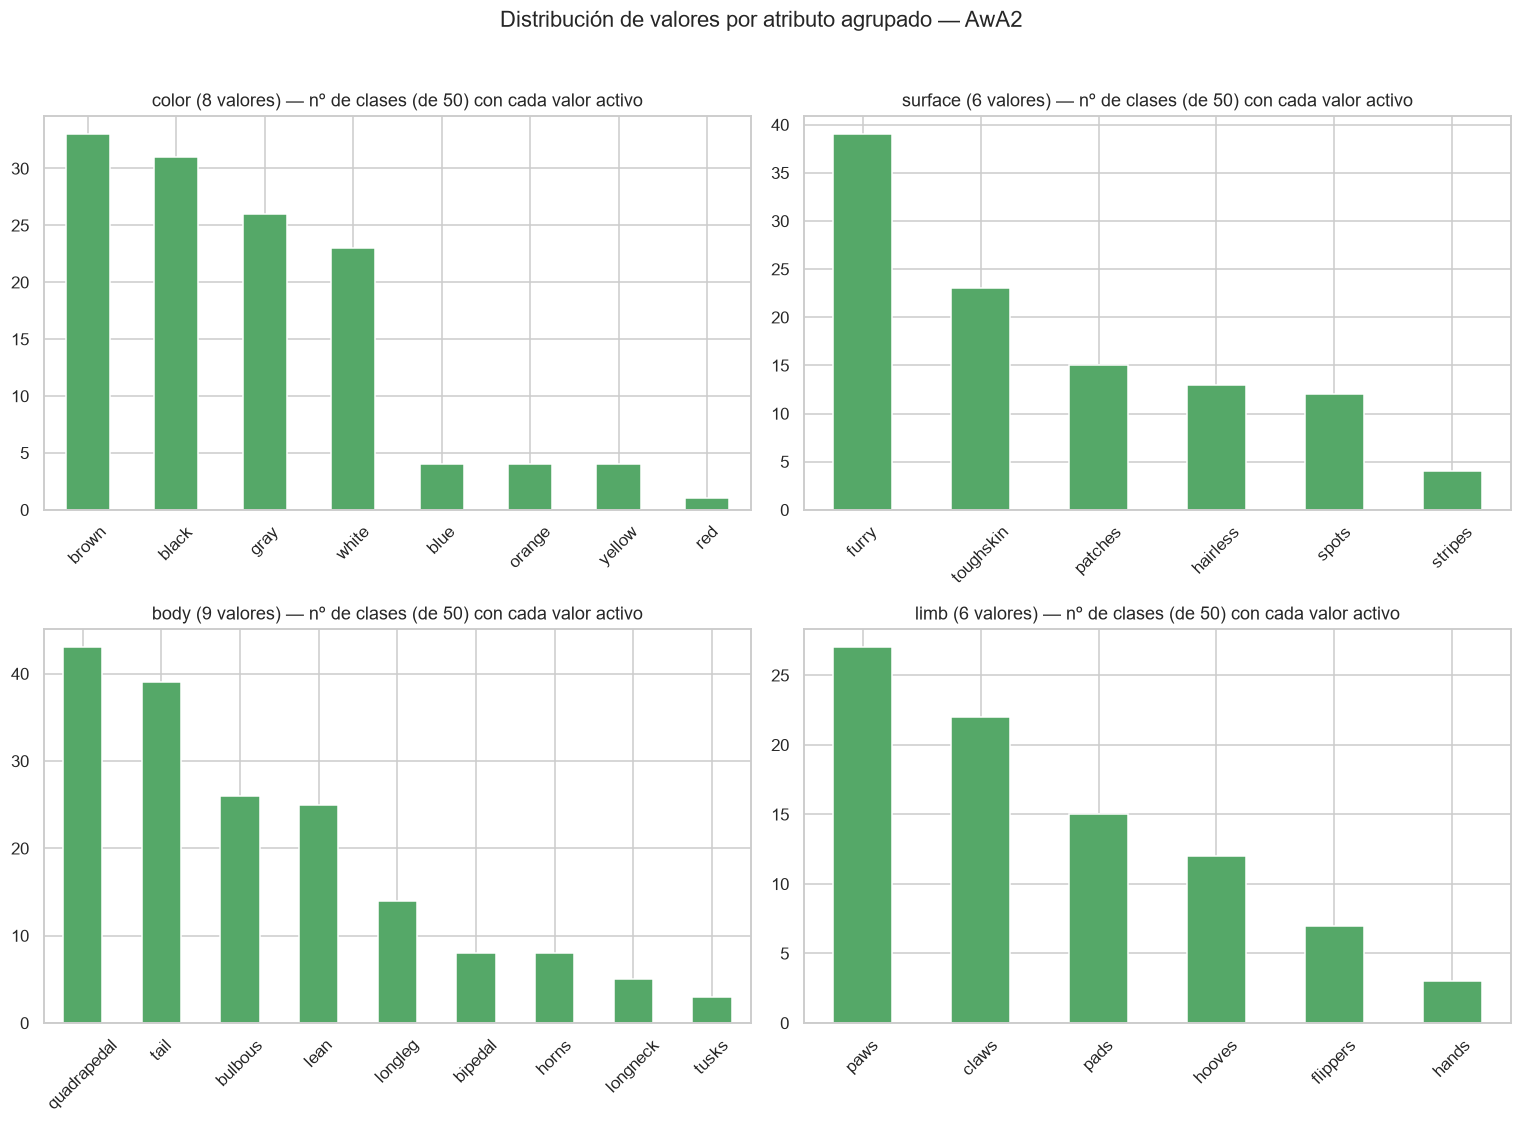

In [23]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for ax, (attr_name, concepts) in zip(axes.flat, attribute_types.items()):
    sub = awa2_df[concepts]
    counts = sub.sum(axis=0).sort_values(ascending=False)
    counts.plot(kind="bar", ax=ax, color="#55A868")
    ax.set_title(f"{attr_name} ({len(concepts)} valores) — nº de clases (de 50) con cada valor activo")
    ax.tick_params(axis="x", labelrotation=45)
fig.suptitle("Distribución de valores por atributo agrupado — AwA2", y=1.02)
savefig("awa2_attribute_value_distributions.png")


In [24]:

# Multi-valued confirmation: how many simultaneously-active values per grouped
# attribute, per class (the zebra black+white example from the paper)
rows = []
for attr_name, concepts in attribute_types.items():
    active_count = awa2_df[concepts].sum(axis=1)
    for k, n_classes in active_count.value_counts().sort_index().items():
        rows.append({"attribute": attr_name, "n_active_values": int(k), "n_classes": int(n_classes)})

multi_awa2 = pd.DataFrame(rows)
pivot_awa2 = multi_awa2.pivot(index="attribute", columns="n_active_values", values="n_classes").fillna(0)
print(pivot_awa2)

zebra_colors = [c for c in attribute_types["color"] if awa2_df.loc["zebra", c] == 1] if "zebra" in awa2_df.index else []
print(f"\nZebra's active 'color' values (paper's own example): {zebra_colors}")


n_active_values    0     1     2     3     4    5    6
attribute                                             
body             0.0   1.0   9.0  20.0  11.0  6.0  3.0
color            1.0   7.0  16.0  17.0   9.0  0.0  0.0
limb             2.0  25.0   8.0  15.0   0.0  0.0  0.0
surface          0.0  13.0  23.0   9.0   5.0  0.0  0.0

Zebra's active 'color' values (paper's own example): ['black', 'white']


Saved C:\Users\bspd2\Maestria\Tesis_KDM_NPC\notebooks\figures\awa2_multivalued_attributes.png


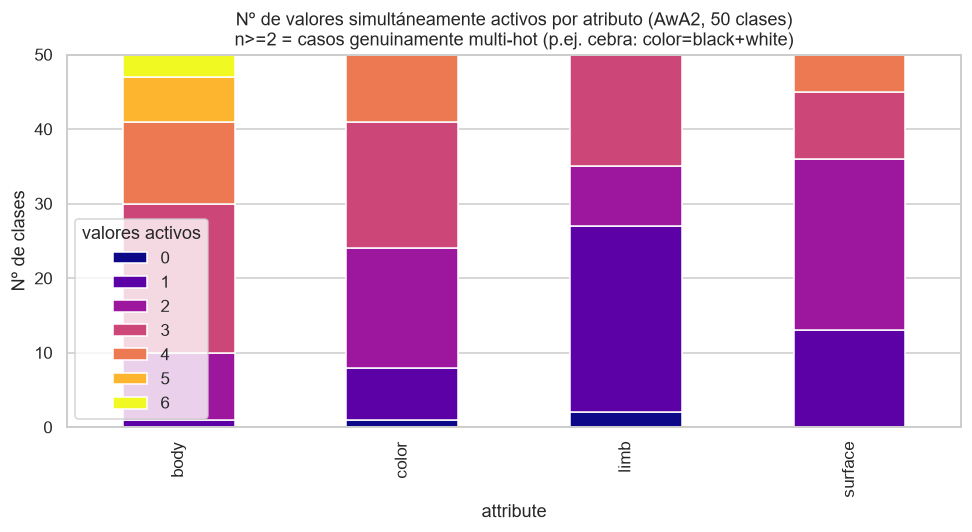

In [25]:

fig, ax = plt.subplots(figsize=(9, 5))
pivot_awa2.plot(kind="bar", stacked=True, ax=ax, colormap="plasma")
ax.set_title("Nº de valores simultáneamente activos por atributo (AwA2, 50 clases)\n"
             "n>=2 = casos genuinamente multi-hot (p.ej. cebra: color=black+white)")
ax.set_ylabel("Nº de clases")
ax.legend(title="valores activos")
savefig("awa2_multivalued_attributes.png")


**Observación clave:** a diferencia de CelebA (anotación por instancia),
AwA2 anota a nivel de **clase completa** — todas las imágenes de "cebra" heredan
exactamente el mismo vector de atributos. Esto simplifica el preprocesamiento
(no hay ruido de anotación por imagen) pero también significa que el "atributo"
en AwA2 es, estrictamente, una propiedad de la clase, no de la instancia — una
diferencia estructural relevante para diseñar el encoder de KDM: en AwA2 el
encoder debe aprender a inferir una propiedad de clase a partir de instancias
individuales variadas (pose, iluminación, fondo), mientras que en MNIST-Addition
el atributo depende directamente y únicamente de los píxeles observados.

## 5. Resumen comparativo entre los 4 datasets

In [26]:

summary = pd.DataFrame([
    {"dataset": "MNIST-Addition", "n_samples": len(mnist_add), "n_classes": mnist_add["class_sum"].nunique(),
     "n_attributes": 2, "avg_values_per_attr": 10, "annotation_level": "instance", "multi_valued": "no"},
    {"dataset": "GTSRB", "n_samples": len(gtsrb_all), "n_classes": gtsrb_all["class_id"].nunique(),
     "n_attributes": 4, "avg_values_per_attr": np.mean([3, 4, len(gtsrb_attr_schema['symbol']), 10]),
     "annotation_level": "class (paper-derived)", "multi_valued": "no"},
    {"dataset": "CelebA", "n_samples": len(celeba_attr), "n_classes": n_final_classes,
     "n_attributes": 5, "avg_values_per_attr": np.mean([len(v) for v in attribute_types.items()]),
     "annotation_level": "instance", "multi_valued": "yes (mouth, cosmetic)"},
    {"dataset": "AwA2", "n_samples": 37322, "n_classes": len(awa2_classes),
     "n_attributes": 4, "avg_values_per_attr": np.mean([8, 6, 9, 6]),
     "annotation_level": "class", "multi_valued": "yes (all 4 attrs)"},
])
summary


,dataset,n_samples,n_classes,n_attributes,avg_values_per_attr,annotation_level,multi_valued
0,MNIST-Addition,35000,19,2,10.00,instance,no
1,GTSRB,39270,43,4,10.75,class (paper-derived),no
2,CelebA,202599,127,5,2.00,instance,"yes (mouth, cosmetic)"
3,AwA2,37322,50,4,7.25,class,yes (all 4 attrs)


In [27]:

summary.to_csv(f"{FIG_DIR}/../dataset_summary.csv", index=False)
print("Saved dataset_summary.csv")
summary


Saved dataset_summary.csv


,dataset,n_samples,n_classes,n_attributes,avg_values_per_attr,annotation_level,multi_valued
0,MNIST-Addition,35000,19,2,10.00,instance,no
1,GTSRB,39270,43,4,10.75,class (paper-derived),no
2,CelebA,202599,127,5,2.00,instance,"yes (mouth, cosmetic)"
3,AwA2,37322,50,4,7.25,class,yes (all 4 attrs)
